In [4]:
import pandas as pd

In [8]:
customers = pd.read_csv("CUSTOMERS.csv")
orders = pd.read_csv("ORDERS.csv")
order_items = pd.read_csv("ORDER_ITEMS.csv")
payments = pd.read_csv("ORDER_PAYMENTS.csv")
reviews = pd.read_csv("ORDER_REVIEW_RATINGS.csv")
products = pd.read_csv("PRODUCTS.csv")
sellers = pd.read_csv("SELLERS.csv")
geo = pd.read_csv("GEO_LOCATION.csv")

In [9]:
df = orders.merge(order_items, on='order_id', how='left') \
           .merge(products, on='product_id', how='left') \
           .merge(customers, on='customer_id', how='left') \
           .merge(payments, on='order_id', how='left') \
           .merge(reviews, on='order_id', how='left')

In [11]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00,1.0,87285b34884572647811a353c7ac498a,...,Akkarampalle,Andhra Pradesh,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,10/11/2017 0:00,10/12/2017 3:43
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00,1.0,87285b34884572647811a353c7ac498a,...,Akkarampalle,Andhra Pradesh,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,10/11/2017 0:00,10/12/2017 3:43
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00,1.0,87285b34884572647811a353c7ac498a,...,Akkarampalle,Andhra Pradesh,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,10/11/2017 0:00,10/12/2017 3:43
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,Pandariya,Chhattisgarh,1.0,UPI,1.0,141.46,8d5266042046a06655c8db133d120ba5,4,8/8/2018 0:00,8/8/2018 18:37
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00,1.0,aa4383b373c6aca5d8797843e5594415,...,Dhamdha,Chhattisgarh,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,8/18/2018 0:00,8/22/2018 19:07


In [12]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 177
order_delivered_carrier_date     2086
order_delivered_customer_date    3421
order_estimated_delivery_date       0
order_item_id                     833
product_id                        833
seller_id                         833
shipping_limit_date               833
price                             833
freight_value                     833
product_category_name            2567
product_name_lenght              2542
product_description_lenght       2542
product_photos_qty               2542
product_weight_g                  853
product_length_cm                 853
product_height_cm                 853
product_width_cm                  853
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
payment_sequ

In [13]:
df['is_delivered'] = df['order_delivered_customer_date'].notnull()

In [14]:
df[df['product_id'].isnull()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_creation_date,review_answer_timestamp,is_delivered
319,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,11/16/2017 15:09,11/16/2017 15:26,NaN,NaN,12/5/2017 0:00,NaN,NaN,...,Chhattisgarh,1.0,credit_card,5.0,84.00,7fb04ba6e8b915c62557517d5c1e04ee,1,12/7/2017 0:00,12/11/2017 10:37,False
702,c272bcd21c287498b4883c7512019702,9582c5bbecc65eb568e2c1d839b5cba1,unavailable,1/31/2018 11:31,1/31/2018 14:23,NaN,NaN,2/16/2018 0:00,NaN,NaN,...,Haryana,1.0,credit_card,1.0,97.68,b6ea5566d6060db04ebe53a1291e4541,3,2/18/2018 0:00,2/20/2018 19:23,False
828,37553832a3a89c9b2db59701c357ca67,7607cd563696c27ede287e515812d528,unavailable,8/14/2017 17:38,8/17/2017 0:15,NaN,NaN,9/5/2017 0:00,NaN,NaN,...,Andhra Pradesh,1.0,UPI,1.0,132.46,aaeb804fe1828db8cc3d8b52ec38a1fa,1,9/10/2017 0:00,9/12/2017 17:00,False
887,d57e15fb07fd180f06ab3926b39edcd2,470b93b3f1cde85550fc74cd3a476c78,unavailable,1/8/2018 19:39,1/9/2018 7:26,NaN,NaN,2/6/2018 0:00,NaN,NaN,...,Karnataka,1.0,UPI,1.0,134.38,519e62c42f33dce5b47ffddf9fde28df,1,2/9/2018 0:00,2/9/2018 3:22,False
1362,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,8/28/2018 15:26,NaN,NaN,NaN,9/12/2018 0:00,NaN,NaN,...,Andhra Pradesh,1.0,not_defined,1.0,0.00,9c0d840dfe562debfa52a1792bd64bff,1,8/28/2018 0:00,8/28/2018 18:25,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118922,aaab15da689073f8f9aa978a390a69d1,df20748206e4b865b2f14a5eabbfcf34,unavailable,1/16/2018 14:27,1/17/2018 3:37,NaN,NaN,2/6/2018 0:00,NaN,NaN,...,Andhra Pradesh,1.0,UPI,1.0,210.09,396e26da77b10734f3f8b5d5515fef4e,1,2/9/2018 0:00,2/9/2018 10:12,False
118954,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,8/31/2018 16:13,NaN,NaN,NaN,10/1/2018 0:00,NaN,NaN,...,Andhra Pradesh,1.0,voucher,1.0,63.89,16d3db296c46b4411dfc5f8bde882e6d,5,7/24/2018 0:00,7/25/2018 16:26,False
119047,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,9/6/2018 18:45,NaN,NaN,NaN,9/27/2018 0:00,NaN,NaN,...,Andhra Pradesh,1.0,voucher,1.0,107.13,047fd109ced39e02296f6aeb74f6a6f1,4,7/31/2018 0:00,8/2/2018 15:11,False
119048,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,8/23/2017 16:28,8/28/2017 15:44,NaN,NaN,9/15/2017 0:00,NaN,NaN,...,Andhra Pradesh,1.0,credit_card,2.0,195.91,41b9de18e0dd1e085e3c402d1c9b87d0,1,9/20/2017 0:00,9/20/2017 11:20,False


In [16]:
df = df.dropna(subset=['product_id'])

In [18]:
df['product category name'] = df['product_category_name'].fillna('Unknown')

/tmp/ipykernel_367756/3439395313.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['product category name'] = df['product_category_name'].fillna('Unknown')


In [19]:
df.loc[:,'product_category_name'] = df['product_category_name'].fillna('Unknown')

In [20]:
df['product_weight_g'] = df['product_weight_g'].fillna(df['product_weight_g'].median())

/tmp/ipykernel_367756/2705356803.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['product_weight_g'] = df['product_weight_g'].fillna(df['product_weight_g'].median())


In [21]:
df.loc[:, 'product_weight_g'] = df['product_weight_g'].fillna(
    df['product_weight_g'].median()
)

In [23]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_creation_date',
       'review_answer_timestamp', 'is_delivered', 'product category name'],
      dtype='object')

In [25]:
df =  df.dropna(subset=['payment_type'])

In [29]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df = df.drop_duplicates()

In [33]:
total_revenue = df['payment_value'].sum()
print("Total_Revenue:", total_revenue)

Total_Revenue: 20418288.15


In [34]:
total_orders = df['order_id'].nunique()
print("Total_Orders:", total_orders)

Total_Orders: 98665


In [37]:
total_categories = df['product_category_name'].nunique()
print("Total_Categories:", total_categories)

Total_Categories: 72


In [38]:
total_sellers = df['seller_id'].nunique()
print("total_sellers:", total_sellers)

total_sellers: 3095


In [39]:
total_customers = df['customer_id'].nunique()
print("Total Customers:", total_customers)

Total Customers: 98665


In [42]:
total_cities = df['customer_city'].nunique()
print("total_cities :", total_cities)

total_cities : 4110


In [46]:
payment_method = df['payment_type'].nunique()
print("payment_methods:", payment_method)

payment_methods: 4


In [47]:
df['payment_type'].value_counts()

payment_type
credit_card    87266
UPI            23018
voucher         6332
debit_card      1699
Name: count, dtype: int64

In [48]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [56]:
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [57]:
first_purchase = df.groupby('customer_id')['year_month'].min().reset_index()

In [58]:
new_customers = first_purchase.groupby('year_month').size()

In [59]:
new_customers = new_customers.reset_index(name='new_customers')

In [60]:
print(new_customers)

   year_month  new_customers
0     2016-09              2
1     2016-10            308
2     2016-12              1
3     2017-01            789
4     2017-02           1733
5     2017-03           2641
6     2017-04           2391
7     2017-05           3660
8     2017-06           3217
9     2017-07           3969
10    2017-08           4293
11    2017-09           4243
12    2017-10           4568
13    2017-11           7451
14    2017-12           5624
15    2018-01           7220
16    2018-02           6694
17    2018-03           7188
18    2018-04           6934
19    2018-05           6853
20    2018-06           6160
21    2018-07           6273
22    2018-08           6452
23    2018-09              1


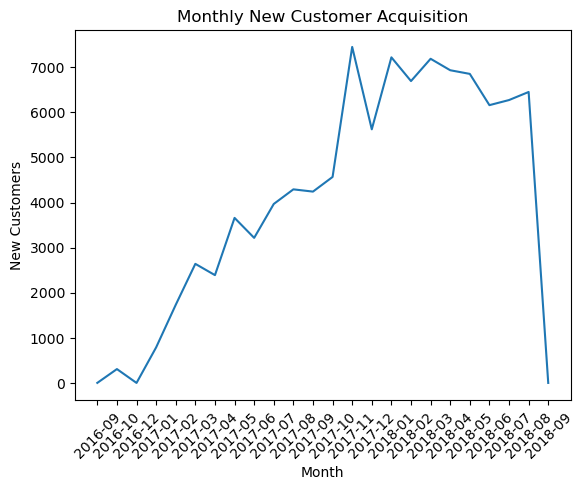

In [61]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(new_customers['year_month'].astype(str), new_customers['new_customers'])
plt.xticks(rotation=45)
plt.title("Monthly New Customer Acquisition")
plt.xlabel("Month")
plt.ylabel("New Customers")
plt.show()

In [62]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [63]:
cohort = df.groupby('customer_id')['order_month'].min().reset_index()
cohort.columns = ['customer_id', 'cohort_month']

In [64]:
df = df.merge(cohort, on='customer_id')

In [67]:
df['month_number'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

In [68]:
cohort_data = df.groupby(['cohort_month', 'month_number'])['customer_id'].nunique().reset_index()

In [69]:
cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='month_number',
    values='customer_id'
)

In [70]:
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

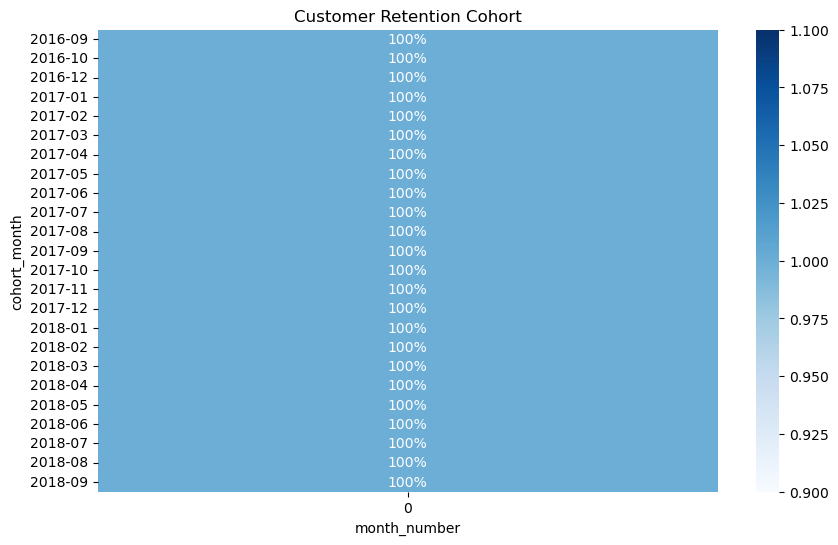

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Customer Retention Cohort")
plt.show()

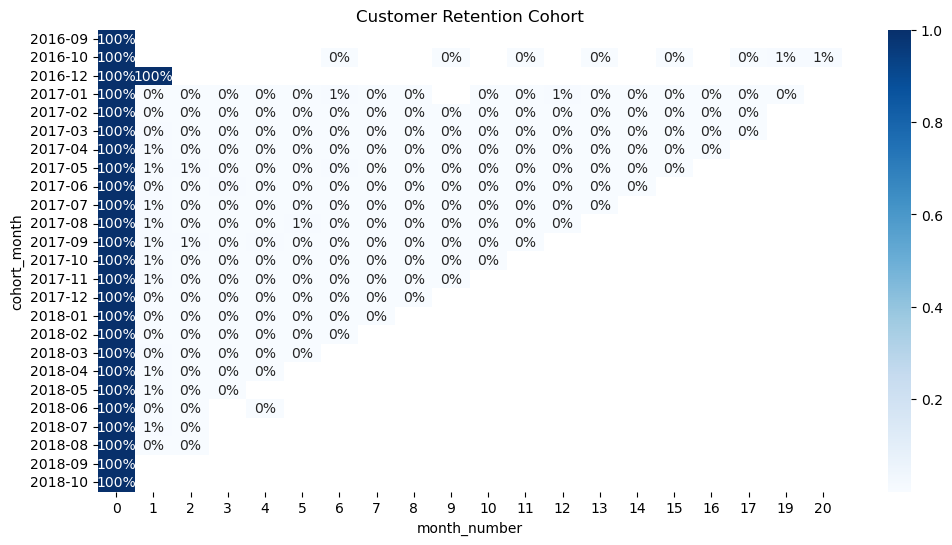

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv("ORDERS.csv")
customers = pd.read_csv("CUSTOMERS.csv")

# Merge
df = orders.merge(customers, on='customer_id')

df = df.copy()

# Convert date
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Month
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# REMOVE duplicates per user per month
df = df.drop_duplicates(subset=['customer_unique_id', 'order_month'])

# Cohort
cohort = df.groupby('customer_unique_id')['order_month'].min().reset_index()
cohort.columns = ['customer_unique_id', 'cohort_month']

df = df.merge(cohort, on='customer_unique_id')

# Month difference
df['month_number'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

# Group
cohort_data = df.groupby(['cohort_month', 'month_number'])['customer_unique_id'] \
                .nunique() \
                .reset_index()

# Pivot
cohort_pivot = cohort_data.pivot(index='cohort_month',
                                 columns='month_number',
                                 values='customer_unique_id')

# Retention
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

# Plot
plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Customer Retention Cohort")
plt.show()

In [85]:
df['customer_type'] = df.apply(
    lambda x: 'New' if x['order_month'] == x['cohort_month'] else 'Existing',
    axis=1
)
payments = pd.read_csv("ORDER_PAYMENTS.csv")

df = df.merge(payments[['order_id','payment_value']], on='order_id', how='left')

In [86]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_month', 'cohort_month', 'month_number',
       'customer_type', 'payment_value'],
      dtype='object')

In [87]:
revenue = df.groupby(['order_month', 'customer_type'])['payment_value'] \
            .sum() \
            .reset_index()

In [88]:
revenue_pivot = revenue.pivot(
    index='order_month',
    columns='customer_type',
    values='payment_value'
).fillna(0)

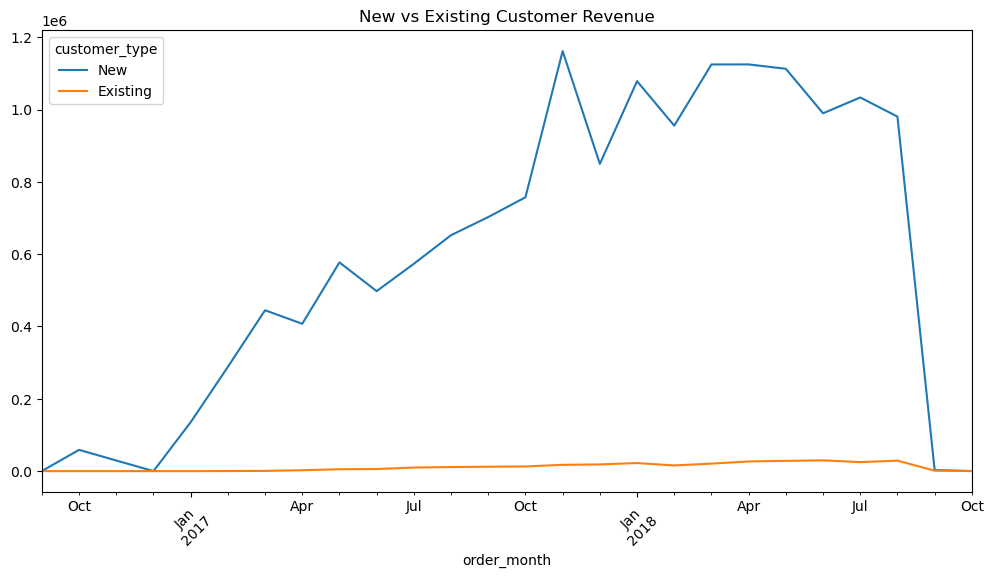

In [90]:
revenue_pivot[['New','Existing']].plot(figsize=(12,6))
plt.xticks(rotation=45)
plt.title("New vs Existing Customer Revenue")
plt.savefig("revenue_chart.png")
plt.show()

In [91]:
df['order_date'] = df['order_purchase_timestamp']

df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()

df['day'] = df['order_date'].dt.day
df['day_of_week'] = df['order_date'].dt.day_name()

df['hour'] = df['order_date'].dt.hour

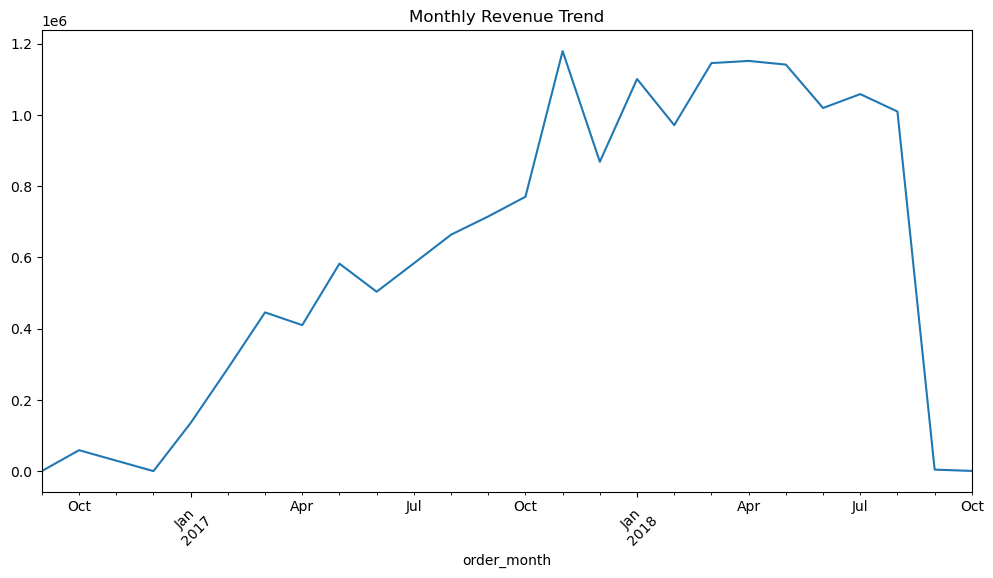

In [92]:
monthly_sales = df.groupby('order_month')['payment_value'].sum()

monthly_sales.plot(figsize=(12,6), title="Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

In [96]:
order_items = pd.read_csv("ORDER_ITEMS.csv")

df = df.merge(order_items[['order_id','product_id']], 
              on='order_id', 
              how='left')

In [97]:
products = pd.read_csv("PRODUCTS.csv")

df = df.merge(products[['product_id','product_category_name']], 
              on='product_id', 
              how='left')products = pd.read_csv("PRODUCTS.csv")

df = df.merge(products[['product_id','product_category_name']], 
              on='product_id', 
              how='left')

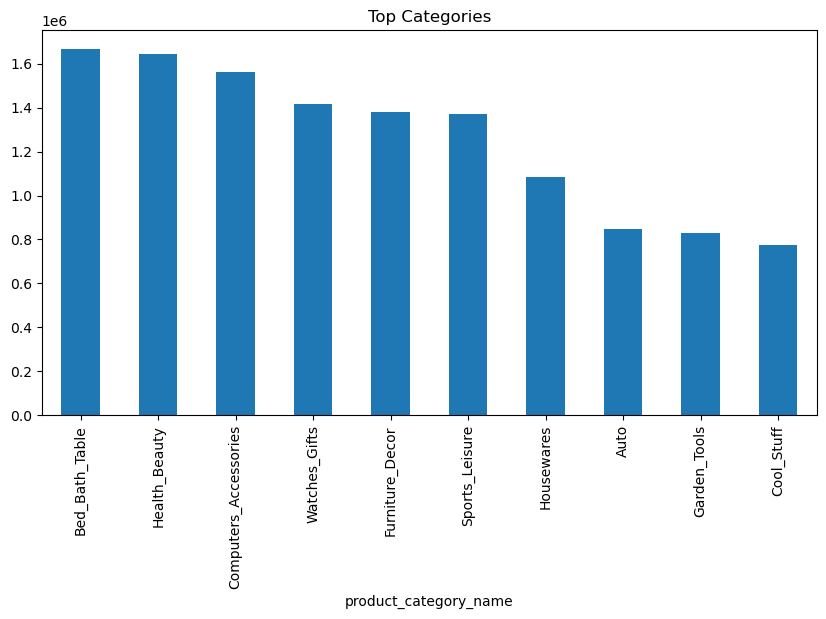

In [98]:
category_sales = df.groupby('product_category_name')['payment_value'] \
                  .sum() \
                  .sort_values(ascending=False)

category_sales.head(10).plot(kind='bar', figsize=(10,5), title="Top Categories")
plt.show()

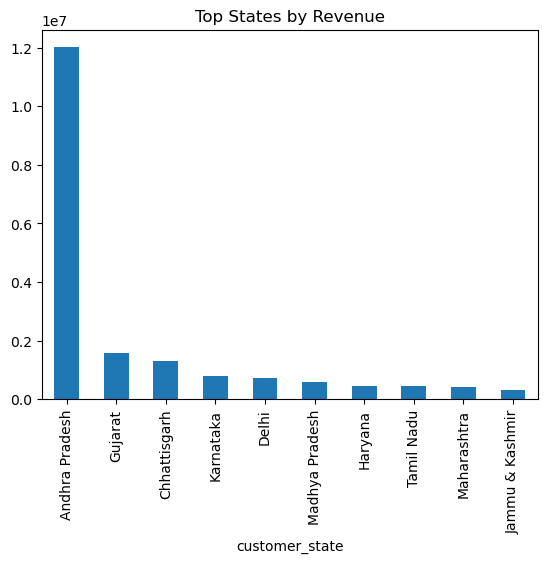

In [99]:
state_sales = df.groupby('customer_state')['payment_value'].sum()

state_sales.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top States by Revenue")
plt.show()

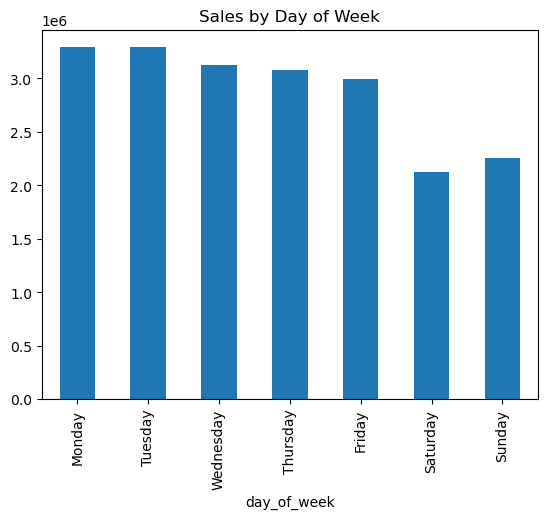

In [101]:
day_sales = df.groupby('day_of_week')['payment_value'].sum()

day_sales = day_sales.reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

day_sales.plot(kind='bar', title="Sales by Day of Week")
plt.show()

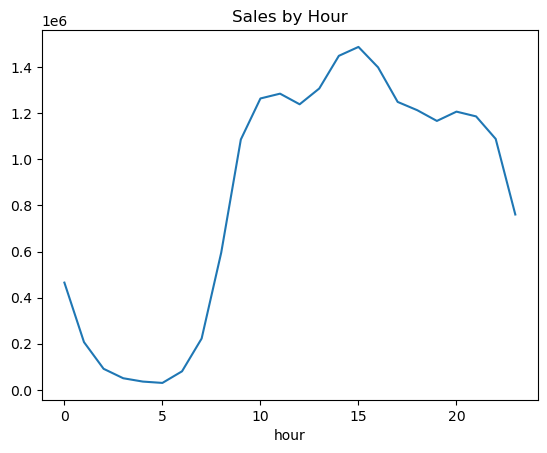

In [102]:
hour_sales = df.groupby('hour')['payment_value'].sum()

hour_sales.plot(title="Sales by Hour")
plt.show()

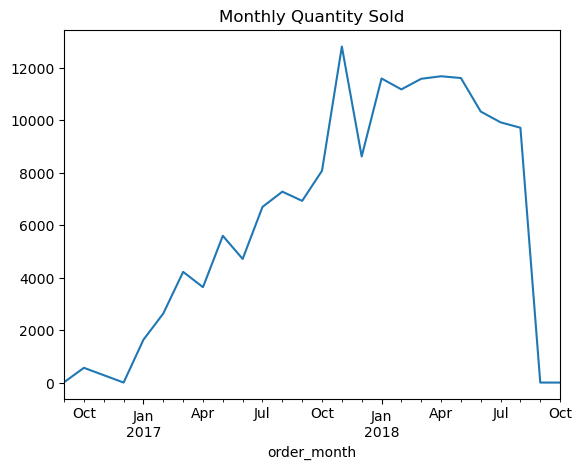

In [104]:
order_items = pd.read_csv("ORDER_ITEMS.csv")

df = df.merge(order_items[['order_id','order_item_id','product_id']], 
              on='order_id', 
              how='left')
quantity_trend = df.groupby('order_month')['order_item_id'].count()

quantity_trend.plot(title="Monthly Quantity Sold")
plt.show()

In [107]:
payments = pd.read_csv("ORDER_PAYMENTS.csv")

# Remove duplicates from payments first
payments_clean = payments[['order_id','payment_type','payment_value']].drop_duplicates()

# Merge into your existing df
df = df.merge(payments_clean, on='order_id', how='left')
payments = pd.read_csv("ORDER_PAYMENTS.csv")

df = df.merge(payments[['order_id','payment_type','payment_value']], 
              on='order_id', 
              how='left')
payment_sales = df.groupby('payment_type')['payment_value'].sum()

payment_sales.plot(kind='bar', title="Payment Method Usage")
plt.show()

MergeError: Passing 'suffixes' which cause duplicate columns {'payment_value_x'} is not allowed.

In [ ]:
quantity_trend = df.groupby('order_month')['order_item_id'].count()

quantity_trend.plot(title="Monthly Quantity Sold")
plt.show()

In [108]:
import pandas as pd

# ==============================
# LOAD ALL TABLES
# ==============================
orders = pd.read_csv("ORDERS.csv")
order_items = pd.read_csv("ORDER_ITEMS.csv")
customers = pd.read_csv("CUSTOMERS.csv")
products = pd.read_csv("PRODUCTS.csv")
payments = pd.read_csv("ORDER_PAYMENTS.csv")
reviews = pd.read_csv("ORDER_REVIEW_RATINGS.csv")

# ==============================
# CLEAN PAYMENTS (IMPORTANT)
# ==============================
payments = payments.groupby('order_id', as_index=False).agg({
    'payment_value': 'sum',
    'payment_type': 'first'
})

# ==============================
# MERGE ALL TABLES STEP-BY-STEP
# ==============================

# Orders + Customers
df = orders.merge(customers, on='customer_id', how='left')

# + Order Items
df = df.merge(order_items, on='order_id', how='left')

# + Products
df = df.merge(products, on='product_id', how='left')

# + Payments
df = df.merge(payments, on='order_id', how='left')

# + Reviews (optional)
df = df.merge(reviews, on='order_id', how='left')

# ==============================
# FINAL COPY (AVOID WARNINGS)
# ==============================
df = df.copy()


===== KPI METRICS =====
Total Revenue: 16995784.92
Total Orders: 99441
Total Customers: 96096
Total Sellers: 3095
Total Products: 32951
Total Categories: 71
Total States: 20
Payment Methods: 5


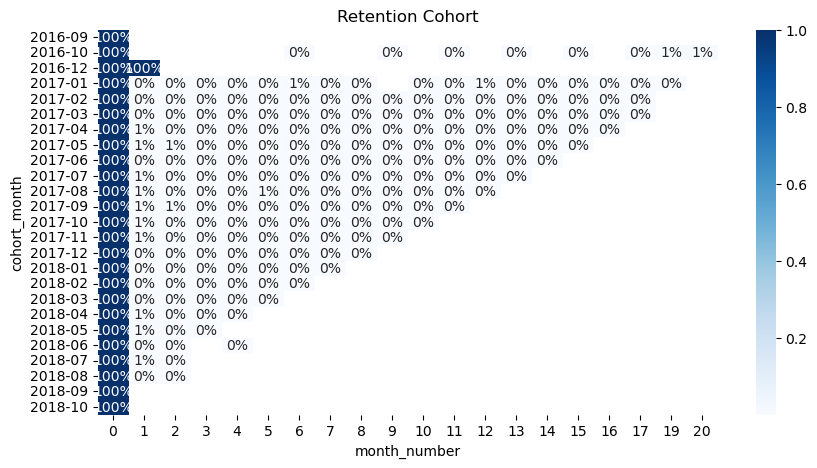

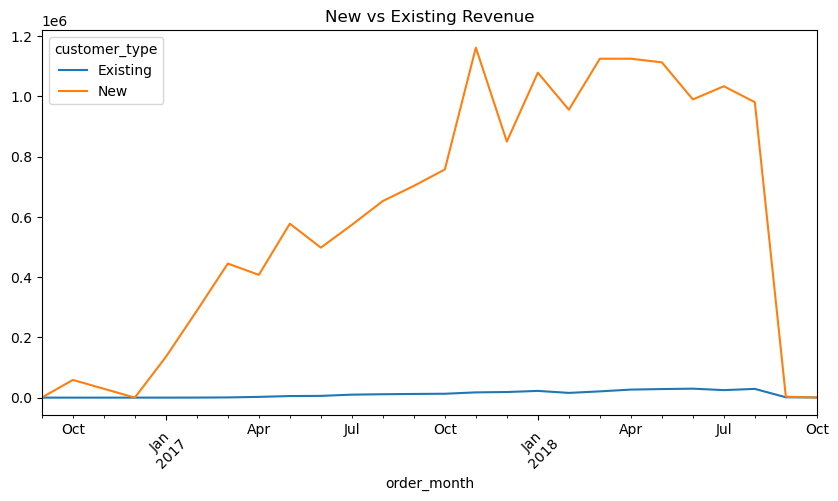

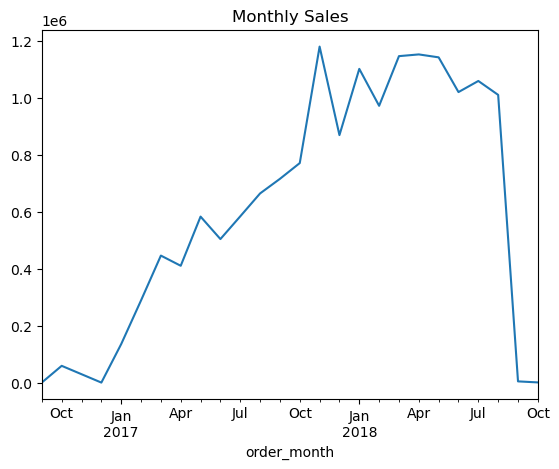

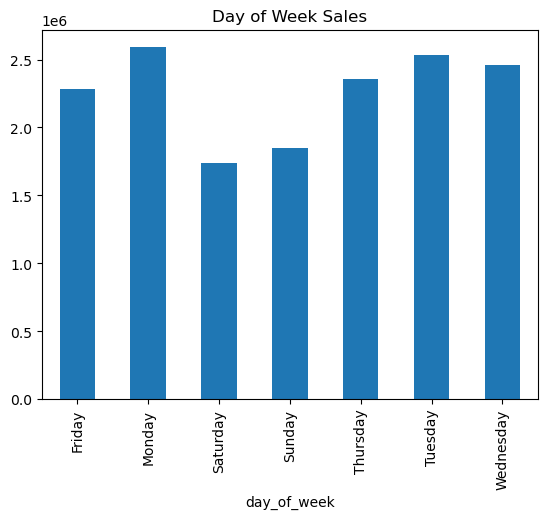

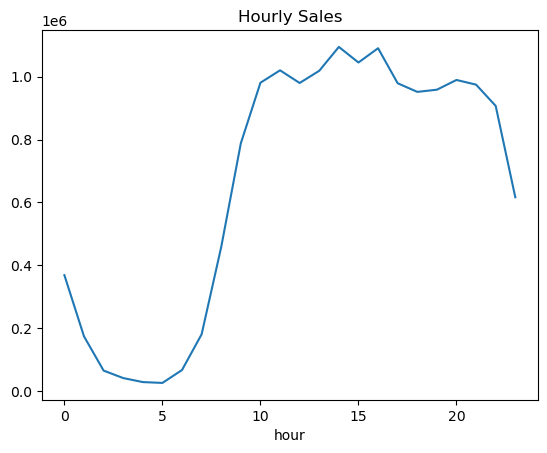

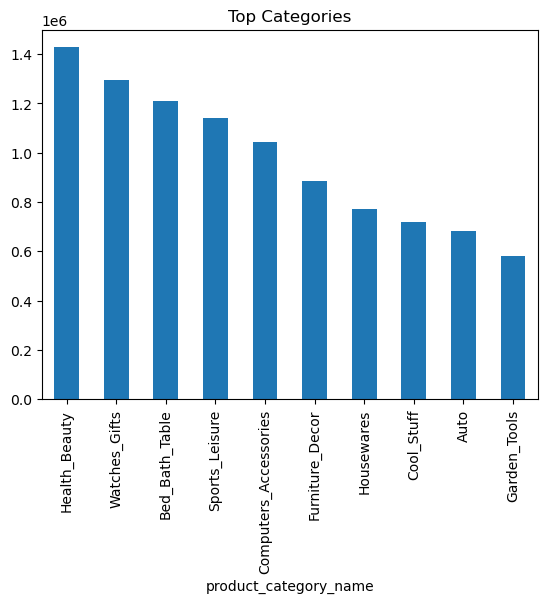

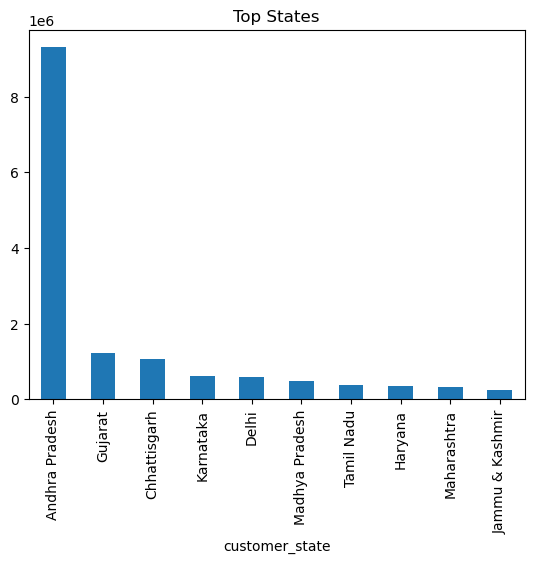

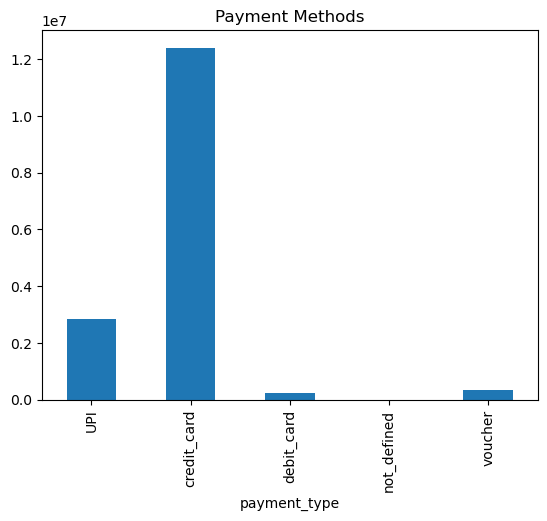


Top Products:
product_id
bb50f2e236e5eea0100680137654686c    67705.55
d1c427060a0f73f6b889a5c7c61f2ac4    61018.82
6cdd53843498f92890544667809f1595    58527.55
99a4788cb24856965c36a24e339b6058    50387.72
3dd2a17168ec895c781a9191c1e95ad7    47677.87
d6160fb7873f184099d9bc95e30376af    47417.72
aca2eb7d00ea1a7b8ebd4e68314663af    44303.92
5f504b3a1c75b73d6151be81eb05bdc9    40989.84
53b36df67ebb7c41585e8d54d6772e08    39531.46
25c38557cf793876c5abdd5931f922db    39237.25
Name: payment_value, dtype: float64

Top Expensive Products:
                             product_id    price
22097  489ae2aa008f021502940f251d4cce7f  6735.00
28216  69c590f7ffc7bf8db97190b6cb6ed62e  6729.00
3507   1bdf5e6731585cf01aa8169c7028d6ad  6499.00
40089  c3ed642d592594bb648ff4a04cee2747  4690.00
40104  259037a6a41845e455183f89c5035f18  4590.00
11672  a1beef8f3992dbd4cd8726796aa69c53  4399.87
19408  6cdf8fc1d741c76586d8b6b15e9eef30  4099.99
2694   dd113cb02b2af9c8e5787e8f1f0722f6  4059.00
56596  6902c1962dd19d5

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

# ==============================
# LOAD DATA
# ==============================
orders = pd.read_csv("ORDERS.csv")
order_items = pd.read_csv("ORDER_ITEMS.csv")
customers = pd.read_csv("CUSTOMERS.csv")
products = pd.read_csv("PRODUCTS.csv")
payments = pd.read_csv("ORDER_PAYMENTS.csv")
reviews = pd.read_csv("ORDER_REVIEW_RATINGS.csv")

# ==============================
# CLEAN PAYMENTS (avoid duplication)
# ==============================
payments = payments.groupby('order_id', as_index=False).agg({
    'payment_value': 'sum',
    'payment_type': 'first'
})

# ==============================
# MERGE ALL TABLES
# ==============================
df = orders.merge(customers, on='customer_id', how='left') \
           .merge(order_items, on='order_id', how='left') \
           .merge(products, on='product_id', how='left') \
           .merge(payments, on='order_id', how='left') \
           .merge(reviews, on='order_id', how='left')

df = df.copy()

# ==============================
# DATE FEATURES
# ==============================
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()
df['hour'] = df['order_purchase_timestamp'].dt.hour

# ==============================
# KPI METRICS
# ==============================
df_orders = df[['order_id','customer_unique_id','seller_id','payment_value',
                'product_id','product_category_name','customer_state',
                'payment_type']].drop_duplicates()

print("\n===== KPI METRICS =====")
print("Total Revenue:", df_orders['payment_value'].sum())
print("Total Orders:", df_orders['order_id'].nunique())
print("Total Customers:", df_orders['customer_unique_id'].nunique())
print("Total Sellers:", df_orders['seller_id'].nunique())
print("Total Products:", df_orders['product_id'].nunique())
print("Total Categories:", df_orders['product_category_name'].nunique())
print("Total States:", df_orders['customer_state'].nunique())
print("Payment Methods:", df_orders['payment_type'].nunique())

# ==============================
# NEW CUSTOMERS
# ==============================
first_purchase = df.groupby('customer_unique_id')['order_month'].min().reset_index()
new_customers = first_purchase.groupby('order_month').size()

# ==============================
# COHORT RETENTION
# ==============================
df = df.drop_duplicates(subset=['customer_unique_id','order_month'])

cohort = df.groupby('customer_unique_id')['order_month'].min().reset_index()
cohort.columns = ['customer_unique_id','cohort_month']
df = df.merge(cohort, on='customer_unique_id')

df['month_number'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

cohort_data = df.groupby(['cohort_month','month_number'])['customer_unique_id'].nunique().reset_index()

cohort_pivot = cohort_data.pivot(index='cohort_month', columns='month_number', values='customer_unique_id')

retention = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0)

plt.figure(figsize=(10,5))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Retention Cohort")
plt.savefig("Retention_Cohort.png")
plt.show()

# ==============================
# NEW VS EXISTING REVENUE
# ==============================
df['customer_type'] = df.apply(
    lambda x: 'New' if x['order_month']==x['cohort_month'] else 'Existing',
    axis=1
)

rev = df.groupby(['order_month','customer_type'])['payment_value'].sum().reset_index()
rev_pivot = rev.pivot(index='order_month', columns='customer_type', values='payment_value').fillna(0)

rev_pivot.plot(figsize=(10,5), title="New vs Existing Revenue")
plt.xticks(rotation=45)
plt.savefig("New_vs_Existing_Revenue.png")
plt.show()

# ==============================
# TRENDS
# ==============================
df.groupby('order_month')['payment_value'].sum().plot(title="Monthly Sales")
plt.savefig("revenue_chart.png")
plt.show()

df.groupby('day_of_week')['payment_value'].sum().plot(kind='bar', title="Day of Week Sales")
plt.savefig("Day_of_Week_sales.png")
plt.show()

df.groupby('hour')['payment_value'].sum().plot(title="Hourly Sales")
plt.savefig("Hourly_sales.png")
plt.show()

# ==============================
# CATEGORY
# ==============================
df.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Categories")
plt.savefig("TOp_Categories.png")
plt.show()

# ==============================
# LOCATION
# ==============================
df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top States")
plt.savefig("Top_States.png")
plt.show()

# ==============================
# PAYMENT
# ==============================
df.groupby('payment_type')['payment_value'].sum().plot(kind='bar')
plt.title("Payment Methods")
plt.savefig("Payment_Methods.png")
plt.show()

# ==============================
# POPULAR PRODUCTS
# ==============================
print("\nTop Products:")
print(df.groupby('product_id')['payment_value'].sum().sort_values(ascending=False).head(10))

# ==============================
# EXPENSIVE PRODUCTS
# ==============================
print("\nTop Expensive Products:")
print(df[['product_id','price']].drop_duplicates().sort_values(by='price', ascending=False).head(10))

# ==============================
# CUSTOMER SEGMENTATION
# ==============================
cust_rev = df.groupby('customer_unique_id')['payment_value'].sum()

def segment(x):
    if x > 10000: return "High"
    elif x > 5000: return "Medium"
    else: return "Low"

cust_segment = cust_rev.apply(segment)
print("\nCustomer Segments:")
print(cust_segment.value_counts())

# ==============================
# SELLER SEGMENTATION
# ==============================
seller_rev = df.groupby('seller_id')['payment_value'].sum()
seller_segment = seller_rev.apply(segment)
print("\nSeller Segments:")
print(seller_segment.value_counts())

# ==============================
# CROSS SELLING
# ==============================
basket = df.groupby('order_id')['product_id'].apply(list)

pairs = []
for items in basket:
    pairs.extend(combinations(items, 2))

print("\nTop Cross Sell Pairs:")
print(Counter(pairs).most_common(10))

# ==============================
# CUSTOMER SATISFACTION
# ==============================
print("\nTop Rated Categories:")
print(df.groupby('product_category_name')['review_score'].mean().sort_values(ascending=False).head(10))

print("\nLowest Rated Categories:")
print(df.groupby('product_category_name')['review_score'].mean().sort_values().head(10))